<a href="https://colab.research.google.com/github/Chaitralikore/Remote-Sensing/blob/main/Image_Enhancement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Data Loading
Open QGIS and go to Layer > Add Layer > Add Raster Layer.

Select the Landsat 8/9 Red Band file (LC09_B4.TIF)


---
3. Spatial Filtering (SAGA Plugin)
""Gaussian Filter""" (Smoothing):

Tool: SAGA Next Gen > Image Analysis > Filter > Gaussian Filter.

Settings: Standard Deviation (Sigma) = 1.5, Radius = 3.

Goal: To remove high-frequency sensor noise and smooth the image.


---



Laplacian Filter (Edge Detection):

Tool: SAGA Next Gen > Image Analysis > Filter > Laplacian Filter.

Settings: Method = Standard, Radius = 1.

Goal: To highlight boundaries and outlines of clouds or landmasses.


---



Simple Filter (Sharpening):

Tool: SAGA Next Gen > Raster > Filter > Simple Filter.

Settings: Filter = [1] Sharpen, Radius = 1.

Goal: To increase the contrast between adjacent pixels, making the image look "crisper."


---
2. Contrast Stretching (Visual Enhancement)
Accessing Symbology: Right-click the layer > Properties > Symbology.

"""""Technique 1""" (Cumulative Cut):

Set Contrast Enhancement to Stretch to MinMax.

Select Cumulative count cut (Set values to 2.0% and 98.0%).

Set Accuracy to Actual (Slower).

Result: The image becomes brighter and clearer as the extreme 2% of dark and light pixels are ignored.


---



""""""Technique 2""""" (Standard Deviation):

Select Mean +/- standard deviation.

Set the multiplier to 2.00.

Result: Highlights features based on statistical distribution, useful for spotting subtle terrain differences.


---
B PART:
Step 1: Identify the "Dark Object" (The Haze Value)
The goal is to find a pixel that should be black (zero reflectance) but looks grey because of atmospheric scattering.

---Turn on your original Landsat band (LC09_B4).

Select the Identify Features tool (the blue "i" icon you just identified).

Zoom into a deep water body (like a lake or ocean) or a very dark cloud shadow.

Click on the darkest pixel and look at the Value in the Identify Results panel.

Example: Let's assume the value you found is """7200."""


---


Step 2: Atmospheric Correction via Raster Calculator
Now we subtract that haze value from every single pixel in the image to "clear the air."

Go to the top menu: Raster > Raster Calculator...

Expression: (((("LC09_B4@1" - 7200))))

Under Output layer, click the three dots [...] and save it as Exp5_PartB_Corrected.tif.

Click OK.

---


Before Correction: The histogram starts at a high number (e.g., 7500) because of haze.

After Correction: The histogram starts at 0, representing a true physical base where the darkest objects have no reflectance.



---

Conclusion: You have successfully removed the "Path Radiance" (haze), making the image scientifically more accurate.




IN LAPLACIAN: grey grain" which represents the detected edges.


---
Before (No Enhancement):

The image looks very dark or mostly grey.

The difference between the clouds and the water is hard to see.

The histogram is "clumped" in the middle, meaning most pixels have very similar brightness.


---



After (Cumulative Count Cut 2% - 98%):

The whites (clouds) become much brighter.

The blacks (deep water/shadows) become much darker.

The Result: You can suddenly see the "texture" inside the clouds and the shape of the coastline that was hidden before.


---



After (Mean +/- Standard Deviation):

This often makes the image look "harder" or more high-contrast than the 2% cut.

It helps distinguish features that are very close in color (like two different types of vegetation or soil).


In [15]:
import cv2
import matplotlib.pyplot as plt
import os

# Step 1: Define the image path
image_path = '/content/drive/MyDrive/LAB/lab5/LC08__B3.TIF'

# Check if the image file exists
if not os.path.exists(image_path):
    print("Error: The file does not exist at the provided path.")
else:
    # Step 2: Read the image
    image = cv2.imread(image_path)

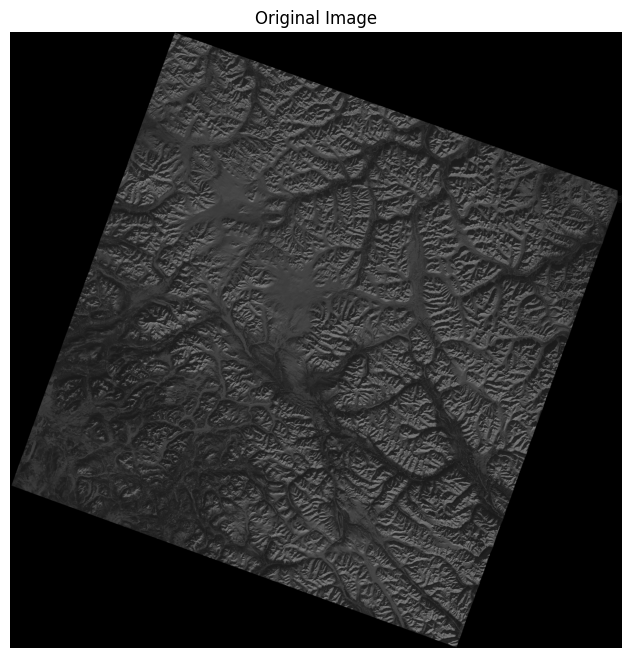

In [16]:
# Convert from BGR (OpenCV default) to RGB (for displaying with matplotlib)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Display the image using matplotlib
plt.figure(figsize=(8, 8))
plt.imshow(image_rgb)
plt.axis('off')
plt.title('Original Image')
plt.show()

In [17]:
# Step 3: Convert the color image to grayscale
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

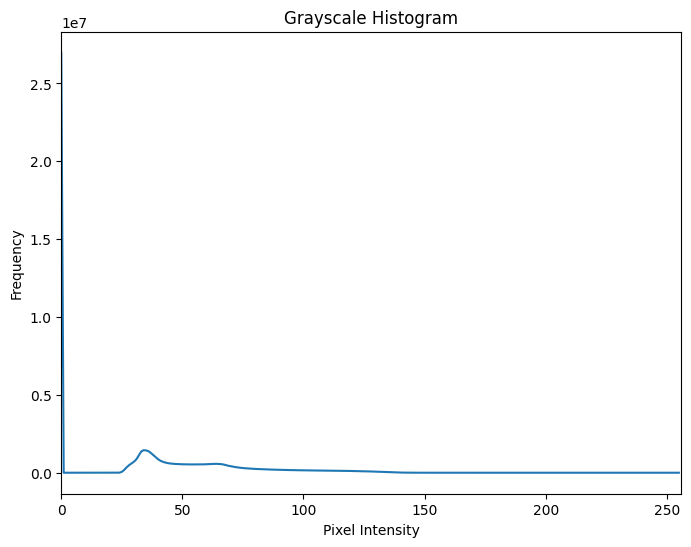

In [18]:
# Step 4: Calculate the histogram of the grayscale image
hist = cv2.calcHist([gray_image], [0], None, [256], [0, 256])

# Plot the histogram
plt.figure(figsize=(8, 6))
plt.title('Grayscale Histogram')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.plot(hist)
plt.xlim([0, 256])
plt.show()

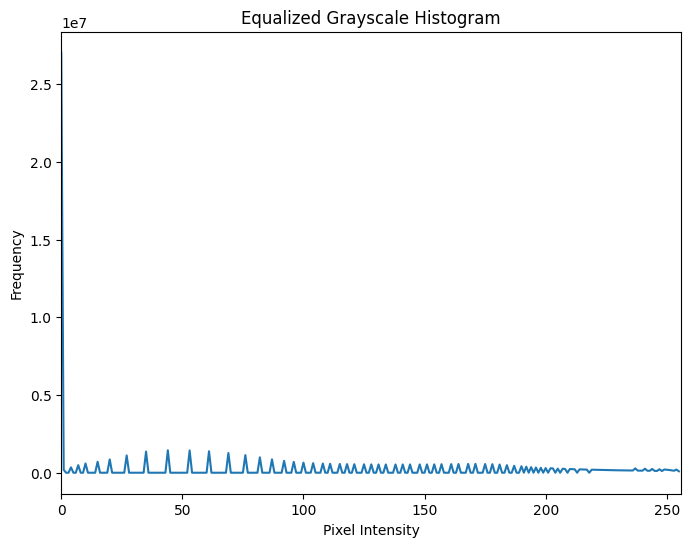

In [19]:
# Step 5: Perform histogram equalization
equalized_image = cv2.equalizeHist(gray_image)

# Plot histogram of the equalized image
equalized_hist = cv2.calcHist([equalized_image], [0], None, [256], [0, 256])
plt.figure(figsize=(8, 6))
plt.title('Equalized Grayscale Histogram')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.plot(equalized_hist)
plt.xlim([0, 256])
plt.show()

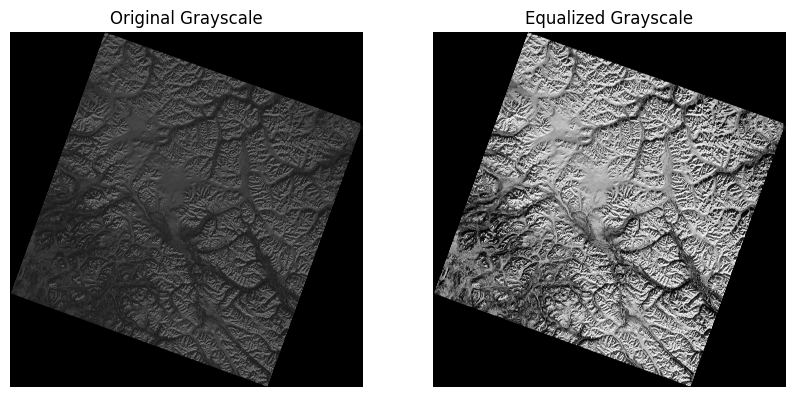

In [20]:
# Display original and histogram equalized image
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(gray_image, cmap='gray')
plt.title('Original Grayscale')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(equalized_image, cmap='gray')
plt.title('Equalized Grayscale')
plt.axis('off')

plt.show()

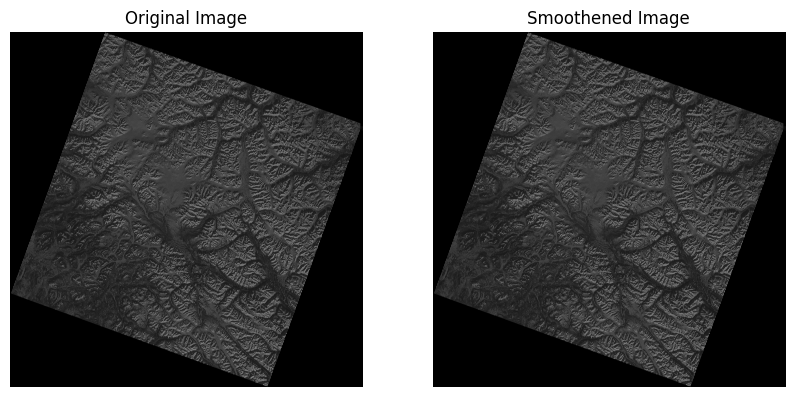

In [21]:
#Smoothening the image using GaussianBlur
smooth_image = cv2.GaussianBlur(image, (5, 5), 0)

# Display original and smoothened image
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(smooth_image, cv2.COLOR_BGR2RGB))
plt.title('Smoothened Image')
plt.axis('off')

plt.show()

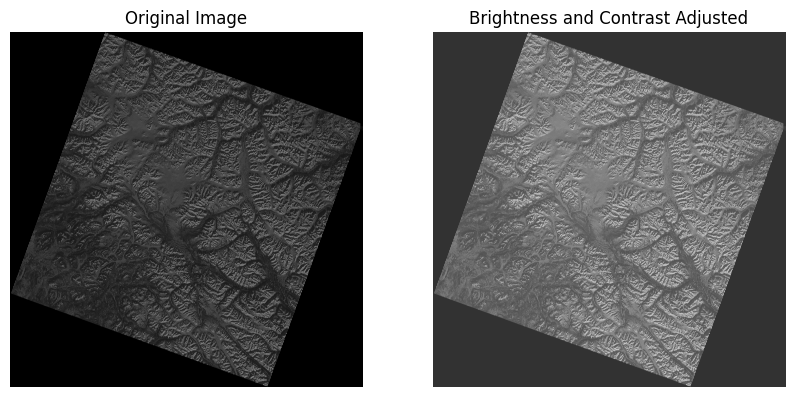

In [22]:
#Change the brightness and contrast using convertScaleAbs()
alpha = 1.2  # Contrast control (1.0 means no change)
beta = 50    # Brightness control (0 means no change)

bright_contrast_image = cv2.convertScaleAbs(image, alpha=alpha, beta=beta)

# Display both original and modified images
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(bright_contrast_image, cv2.COLOR_BGR2RGB))
plt.title('Brightness and Contrast Adjusted')
plt.axis('off')

plt.show()


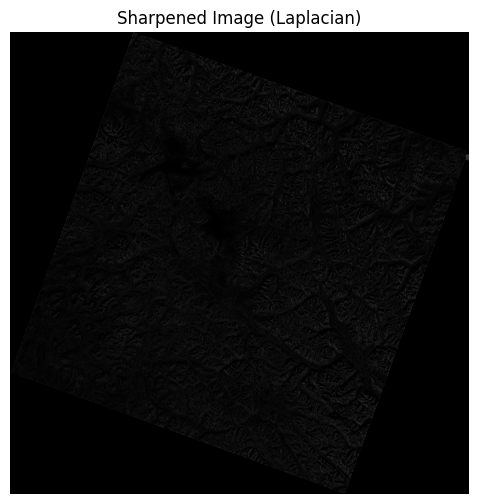

In [23]:

# Sharpen the image using Laplacian
laplacian = cv2.Laplacian(image, cv2.CV_64F)
sharp_image = cv2.convertScaleAbs(laplacian)

# Display the sharp image
plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(sharp_image, cv2.COLOR_BGR2RGB))
plt.title('Sharpened Image (Laplacian)')
plt.axis('off')
plt.show()

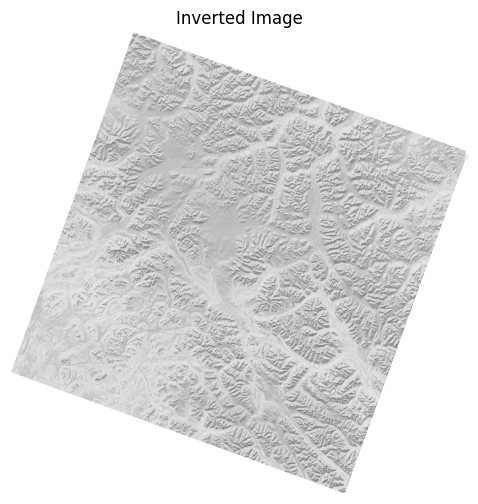

In [24]:

# Inverse the image color
inverted_image = cv2.bitwise_not(image)

# Display the inverted image
plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(inverted_image, cv2.COLOR_BGR2RGB))
plt.title('Inverted Image')
plt.axis('off')
plt.show()

# **Write a Python program to apply DN to radiance correction**

In [25]:
!pip install rasterio


In [27]:
import rasterio
import numpy as np

# Path to the Band 3 file from the MTL metadata
band_3_file = "/content/drive/MyDrive/LAB/lab5/LC08__B3.TIF"

# Radiometric rescaling factors from the MTL file
radiance_mult_band_3 = 1.2045E-02
radiance_add_band_3 = -60.21523

# Open the Band 3 image using rasterio
with rasterio.open(band_3_file) as src:
    band_3_data = src.read(1)  # Read the first band (Band 3)

#DN to radiance
radiance_band_3 = radiance_mult_band_3 * band_3_data + radiance_add_band_3

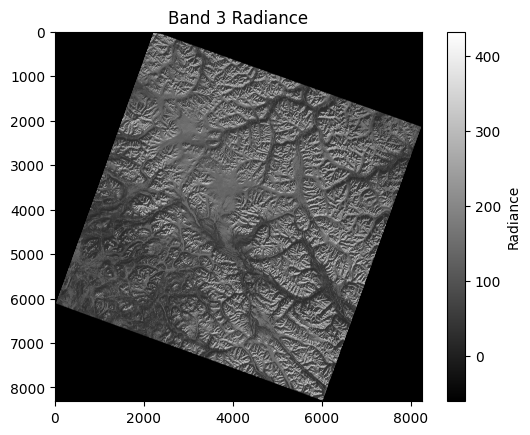

In [28]:
import matplotlib.pyplot as plt

plt.imshow(radiance_band_3, cmap='gray')
plt.colorbar(label='Radiance')
plt.title("Band 3 Radiance")
plt.show()

Radiometric Rescaling: You correctly used the linear formula:$$L_\lambda = M_L \times Q_{cal} + A_L$$where radiance_mult_band_3 ($M_L$) and radiance_add_band_3 ($A_L$) are taken from the metadata (MTL file).

Implementation: You used the rasterio library to handle the geographical data correctly and performed the math using numpy for efficiency.

1. Image Enhancement (Python/OpenCV)
Histogram Equalization: Your code correctly uses cv2.equalizeHist() to spread out the pixel intensities. This is the digital equivalent of the "Contrast Stretching" you performed in QGIS.

Smoothing: You used cv2.GaussianBlur(), which accurately fulfills the objective of applying a Gaussian filter to reduce noise.

Brightness & Contrast: Your use of cv2.convertScaleAbs() with alpha and beta parameters is the standard way to manually adjust image contrast and brightness.

Laplacian (Sharpening): Your code correctly applies cv2.Laplacian() to highlight edges. By converting it back with convertScaleAbs, you ensure the resulting "edge" image is viewable.